# GDP in the Canary Islands (2000-2024)

**Dataset**: Principales resultados del PIB de comunidades autónomas por años desde 2000

**Source**: [ISTAC](https://datos.canarias.es) - GDP by autonomous community, current prices and chained volume indices, 2000-2024

**Questions**: How has Canarias GDP evolved over 25 years? What is the growth trajectory vs national average? How did the 2008 crisis and COVID-19 impact the island economy?

In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
OUTPUT_DIR = Path("output/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = "data/raw/principales-resultados-del-pib-comunidades-autonomas-por-anos-desde-20001.csv"
df = pd.read_csv(CSV_PATH)
print("Rows:", len(df), "| Columns:", len(df.columns))
df = df.rename(columns={
    "MEDIDAS#es": "measure",
    "MEDIDAS_CODE": "measure_code",
    "TERRITORIO#es": "territory",
    "TERRITORIO_CODE": "territory_code",
    "TIME_PERIOD#es": "period",
    "TIME_PERIOD_CODE": "year",
    "OBS_VALUE": "value"
})
df["year"] = df["year"].astype(int)
print("Years:", int(df["year"].min()), "->", int(df["year"].max()))
print("Measures:", sorted(df["measure"].unique()))
df.head(2)

Rows: 2100 | Columns: 10
Years: 2000 -> 2024
Measures: ['Importe a precios de mercado', 'Importe a precios de mercado per cápita', 'Población a 1 de julio', 'Índices de volumen encadenados. Tasa de variación anual']


,measure,measure_code,territory,territory_code,period,year,value,CONFIDENCIALIDAD_OBSERVACION#es,ESTADO_OBSERVACION#es,ESTADO_OBSERVACION_CODE
0,Población a 1 de julio,POB_1_JULIO,España,ES,2000,2000,40554.4,NaN,NaN,NaN
1,Índices de volumen encadenados. Tasa de variac...,INDICES_VOLUMEN_ENCADENADO_TVA,España,ES,2000,2000,NaN,NaN,NaN,NaN


In [2]:
# Filter Canarias and Spain
canarias = df[df["territory_code"] == "ES70"].copy()
spain = df[df["territory_code"] == "ES"].copy()

# Subsets by measure
gdp_total_can = canarias[canarias["measure"] == "Importe a precios de mercado"].sort_values("year")
gdp_pc_can = canarias[canarias["measure"] == "Importe a precios de mercado per cápita"].sort_values("year")
gdp_total_es = spain[spain["measure"] == "Importe a precios de mercado"].sort_values("year")
gdp_pc_es = spain[spain["measure"] == "Importe a precios de mercado per cápita"].sort_values("year")
growth_can = canarias[canarias["measure"] == "Índices de volumen encadenados. Tasa de variación anual"].sort_values("year")
growth_es = spain[spain["measure"] == "Índices de volumen encadenados. Tasa de variación anual"].sort_values("year")

print("GDP total Canarias:", len(gdp_total_can), "rows, years", int(gdp_total_can["year"].min()), "-", int(gdp_total_can["year"].max()))
print("GDP per capita Canarias:", len(gdp_pc_can), "rows")
print("Annual growth rate Canarias:", len(growth_can), "rows, years", int(growth_can["year"].min()), "-", int(growth_can["year"].max()))

GDP total Canarias:

 25 rows, years 2000 - 2024
GDP per capita Canarias: 25 rows
Annual growth rate Canarias: 25 rows, years 2000 - 2024


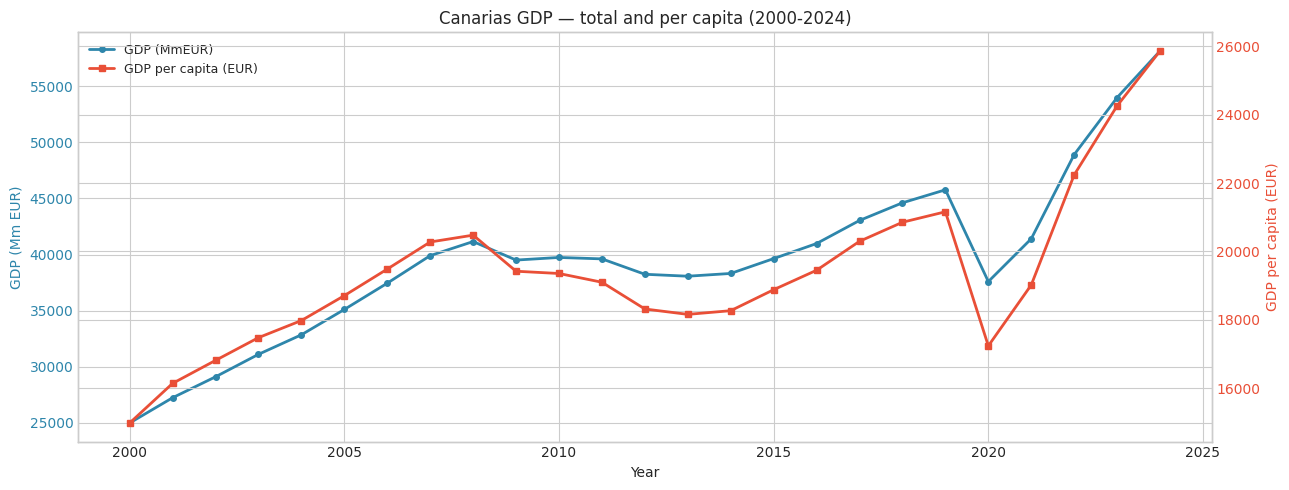

Saved: output/figures/gdp_total_and_per_capita_trend.png


In [3]:
# 1. GDP total and per capita — Canarias trend
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

gdp_valid = gdp_total_can[gdp_total_can["value"].notna()]
pc_valid = gdp_pc_can[gdp_pc_can["value"].notna()]

ax1.plot(gdp_valid["year"], gdp_valid["value"] / 1000, color="#2E86AB", linewidth=2, marker="o", markersize=4, label="GDP (MmEUR)")
ax2.plot(pc_valid["year"], pc_valid["value"], color="#E94F37", linewidth=2, marker="s", markersize=4, label="GDP per capita (EUR)")

ax1.set_xlabel("Year")
ax1.set_ylabel("GDP (Mm EUR)", color="#2E86AB")
ax2.set_ylabel("GDP per capita (EUR)", color="#E94F37")
ax1.tick_params(axis="y", labelcolor="#2E86AB")
ax2.tick_params(axis="y", labelcolor="#E94F37")
ax1.set_title("Canarias GDP — total and per capita (2000-2024)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "gdp_total_and_per_capita_trend.png", dpi=150)
plt.show()
print("Saved: output/figures/gdp_total_and_per_capita_trend.png")

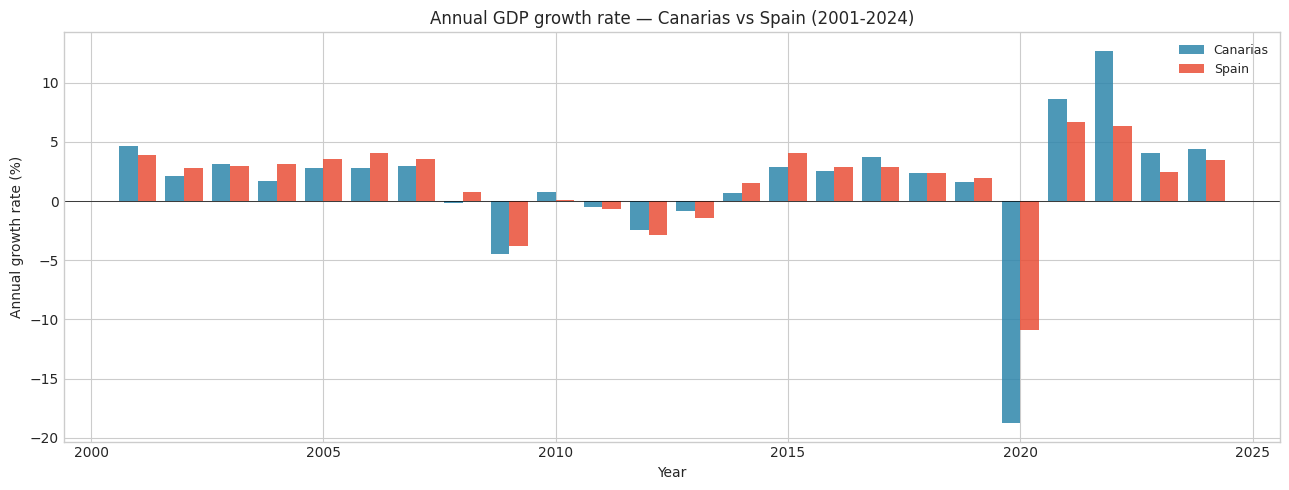

Saved: output/figures/gdp_growth_rate_canarias_vs_spain.png


In [4]:
# 2. Annual GDP growth rate — Canarias vs Spain
fig, ax = plt.subplots(figsize=(13, 5))

growth_valid_can = growth_can[growth_can["value"].notna()]
growth_valid_es = growth_es[growth_es["value"].notna()]

# Align by year
merged = growth_valid_can[["year", "value"]].merge(growth_valid_es[["year", "value"]], on="year", suffixes=("_can", "_es"))

ax.bar(merged["year"] - 0.2, merged["value_can"], width=0.4, label="Canarias", color="#2E86AB", alpha=0.85)
ax.bar(merged["year"] + 0.2, merged["value_es"], width=0.4, label="Spain", color="#E94F37", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Annual growth rate (%)")
ax.set_title("Annual GDP growth rate — Canarias vs Spain (2001-2024)")
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "gdp_growth_rate_canarias_vs_spain.png", dpi=150)
plt.show()
print("Saved: output/figures/gdp_growth_rate_canarias_vs_spain.png")

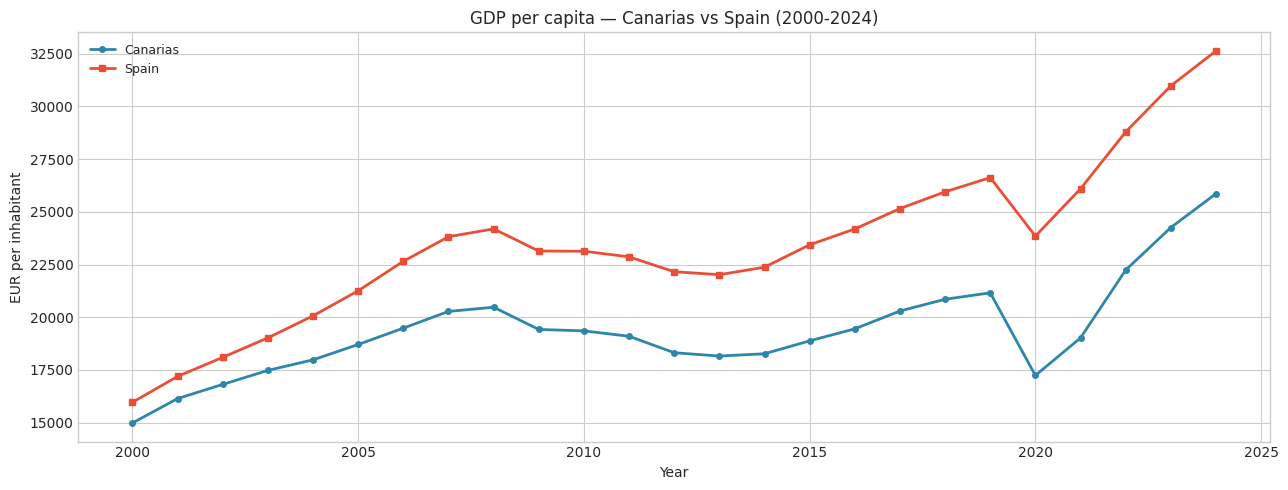

Saved: output/figures/gdp_per_capita_canarias_vs_spain.png


In [5]:
# 3. GDP per capita — Canarias vs Spain over time
fig, ax = plt.subplots(figsize=(13, 5))

pc_can_valid = gdp_pc_can[gdp_pc_can["value"].notna()]
pc_es_valid = gdp_pc_es[gdp_pc_es["value"].notna()]

merged_pc = pc_can_valid[["year", "value"]].merge(pc_es_valid[["year", "value"]], on="year", suffixes=("_can", "_es"))

ax.plot(merged_pc["year"], merged_pc["value_can"], color="#2E86AB", linewidth=2, marker="o", markersize=4, label="Canarias")
ax.plot(merged_pc["year"], merged_pc["value_es"], color="#E94F37", linewidth=2, marker="s", markersize=4, label="Spain")
ax.set_xlabel("Year")
ax.set_ylabel("EUR per inhabitant")
ax.set_title("GDP per capita — Canarias vs Spain (2000-2024)")
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "gdp_per_capita_canarias_vs_spain.png", dpi=150)
plt.show()
print("Saved: output/figures/gdp_per_capita_canarias_vs_spain.png")

In [6]:
# 4. Key numbers
print("=== Key numbers ===")

for label, series in [
    ("GDP total -- Canarias (latest)", gdp_total_can[gdp_total_can["value"].notna()].tail(1)),
    ("GDP per capita -- Canarias (latest)", gdp_pc_can[gdp_pc_can["value"].notna()].tail(1)),
    ("GDP total -- Spain (latest)", gdp_total_es[gdp_total_es["value"].notna()].tail(1)),
    ("GDP per capita -- Spain (latest)", gdp_pc_es[gdp_pc_es["value"].notna()].tail(1)),
]:
    if len(series) > 0:
        row = series.iloc[0]
        print(label + ": " + str(round(row["value"], 0)) + " EUR (" + str(int(row["year"])) + ")")

print()
print("Annual growth rate (latest):")
for label, series in [
    ("Canarias", growth_can[growth_can["value"].notna()].tail(1)),
    ("Spain", growth_es[growth_es["value"].notna()].tail(1)),
]:
    if len(series) > 0:
        row = series.iloc[0]
        print("  " + label + ": " + str(round(row["value"], 2)) + "% (" + str(int(row["year"])) + ")")

print()
print("GDP per capita ratio Canarias/Spain:")
for _, row in merged_pc.dropna().iterrows():
    ratio = row["value_can"] / row["value_es"] * 100
    print("  " + str(int(row["year"])) + ": " + str(round(ratio, 1)) + "%")


=== Key numbers ===
GDP total -- Canarias (latest): 58144618.0 EUR (2024)
GDP per capita -- Canarias (latest): 25861.0 EUR (2024)
GDP total -- Spain (latest): 1594330000.0 EUR (2024)
GDP per capita -- Spain (latest): 32633.0 EUR (2024)

Annual growth rate (latest):
  Canarias: 4.42% (2024)
  Spain: 3.46% (2024)

GDP per capita ratio Canarias/Spain:
  2000: 93.8%
  2001: 93.9%
  2002: 92.9%
  2003: 91.9%
  2004: 89.6%
  2005: 88.0%
  2006: 86.0%
  2007: 85.1%
  2008: 84.6%
  2009: 83.9%
  2010: 83.7%
  2011: 83.5%
  2012: 82.7%
  2013: 82.5%
  2014: 81.6%
  2015: 80.6%
  2016: 80.4%
  2017: 80.7%
  2018: 80.4%
  2019: 79.5%
  2020: 72.3%
  2021: 72.9%
  2022: 77.2%
  2023: 78.3%
  2024: 79.2%
